In [ ]:
import sys, subprocess
subprocess.check_call([
    sys.executable, '-m', 'pip', 'install',
    'xgboost', 'scikit-learn', 'pandas', 'numpy',
    'matplotlib', 'seaborn',
    '--quiet'
])

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve, f1_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

np.random.seed(42)
print('✅ All imports successful!')

✅ All imports successful!


In [ ]:
# ── Option A: Upload directly ─────────────────────────────────────────────────
from google.colab import files
uploaded = files.upload()   # select diabetes_dataset.csv
CSV_PATH = 'diabetes_dataset.csv'

# ── Option B: Google Drive ────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')
CSV_PATH = '/content/drive/MyDrive/diabetes_dataset.csv'

CSV_PATH    = 'diabetes_dataset.csv'
TARGET_COL  = 'Outcome'
CLASS_NAMES = ['No Diabetes', 'Diabetes']

df = pd.read_csv(CSV_PATH)
print(f'Dataset shape : {df.shape}')
print(f'Target counts :')
print(df[TARGET_COL].value_counts().rename({0:'No Diabetes',1:'Diabetes'}).to_string())
df.head()

Saving diabetes_dataset.csv to diabetes_dataset.csv
Mounted at /content/drive
Dataset shape : (1000, 9)
Target counts :
Outcome
No Diabetes    650
Diabetes       350


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,5,63,79,0,129,30.7,0.882,48,0
1,7,120,93,0,79,44.0,0.078,56,1
2,8,78,61,0,124,33.0,0.078,65,0
3,0,133,50,31,95,32.6,0.081,68,0
4,1,123,58,0,17,25.3,1.808,57,1


In [ ]:
print('=== Statistical Summary ===')
df.describe().round(2)

=== Statistical Summary ===


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00
mean,4.32,120.04,68.32,20.26,80.68,31.90,0.48,50.09,0.35
std,4.01,32.35,18.82,14.47,83.67,7.61,0.46,17.40,0.48
min,0.00,44.00,19.00,0.00,0.00,18.00,0.08,21.00,0.00
25%,1.00,98.00,55.00,8.75,22.00,26.60,0.14,35.00,0.00
50%,3.00,119.00,68.00,19.00,55.00,31.60,0.34,50.00,0.00
75%,7.00,142.00,82.00,29.00,111.00,37.10,0.68,65.00,1.00
max,17.00,199.00,122.00,73.00,647.00,57.60,2.42,80.00,1.00


In [ ]:
# Check for suspicious zero values (physiologically impossible)
zero_suspicious = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
print('Zero counts in physiologically suspicious columns:')
for col in zero_suspicious:
    n_zero = (df[col] == 0).sum()
    print(f'  {col:30s}: {n_zero} zeros ({n_zero/len(df)*100:.1f}%)')

Zero counts in physiologically suspicious columns:
  Glucose                       : 0 zeros (0.0%)
  BloodPressure                 : 0 zeros (0.0%)
  SkinThickness                 : 118 zeros (11.8%)
  Insulin                       : 13 zeros (1.3%)
  BMI                           : 0 zeros (0.0%)


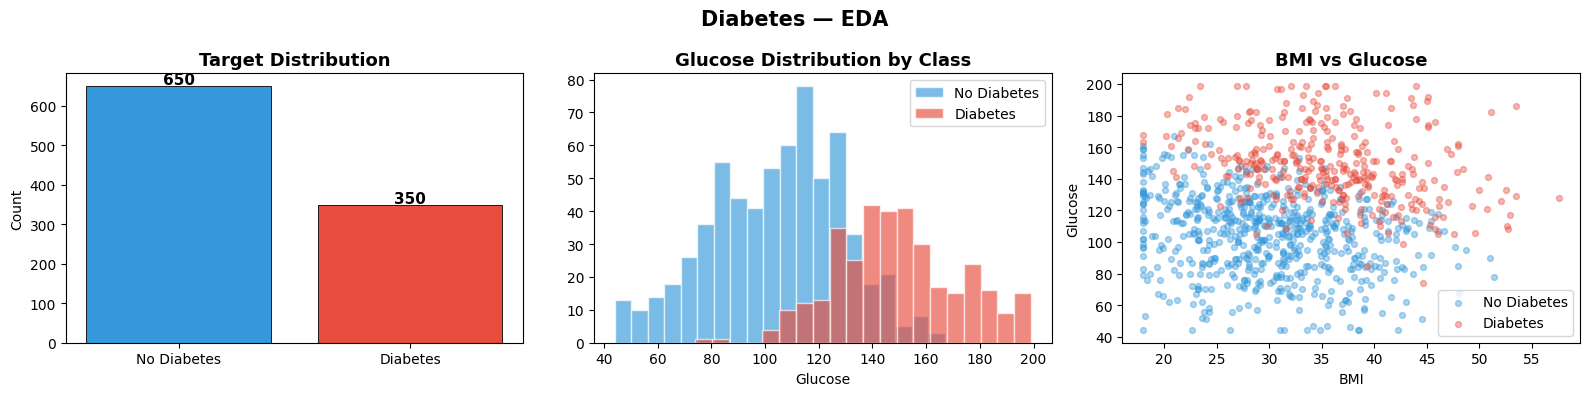

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Target distribution
counts = df[TARGET_COL].value_counts().sort_index()
axes[0].bar(CLASS_NAMES, counts.values, color=['#3498db','#e74c3c'],
            edgecolor='black', linewidth=0.6)
axes[0].set_title('Target Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v+5, str(v), ha='center', fontsize=11, fontweight='bold')

# Glucose distribution by class
for cls, color, label in [(0,'#3498db','No Diabetes'),(1,'#e74c3c','Diabetes')]:
    axes[1].hist(df[df[TARGET_COL]==cls]['Glucose'], bins=20, alpha=0.65,
                 color=color, label=label, edgecolor='white')
axes[1].set_title('Glucose Distribution by Class', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Glucose'); axes[1].legend()

# BMI vs Glucose scatter
for cls, color, label in [(0,'#3498db','No Diabetes'),(1,'#e74c3c','Diabetes')]:
    sub = df[df[TARGET_COL]==cls]
    axes[2].scatter(sub['BMI'], sub['Glucose'], alpha=0.4, c=color, label=label, s=18)
axes[2].set_title('BMI vs Glucose', fontsize=13, fontweight='bold')
axes[2].set_xlabel('BMI'); axes[2].set_ylabel('Glucose')
axes[2].legend()

plt.suptitle('Diabetes — EDA', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

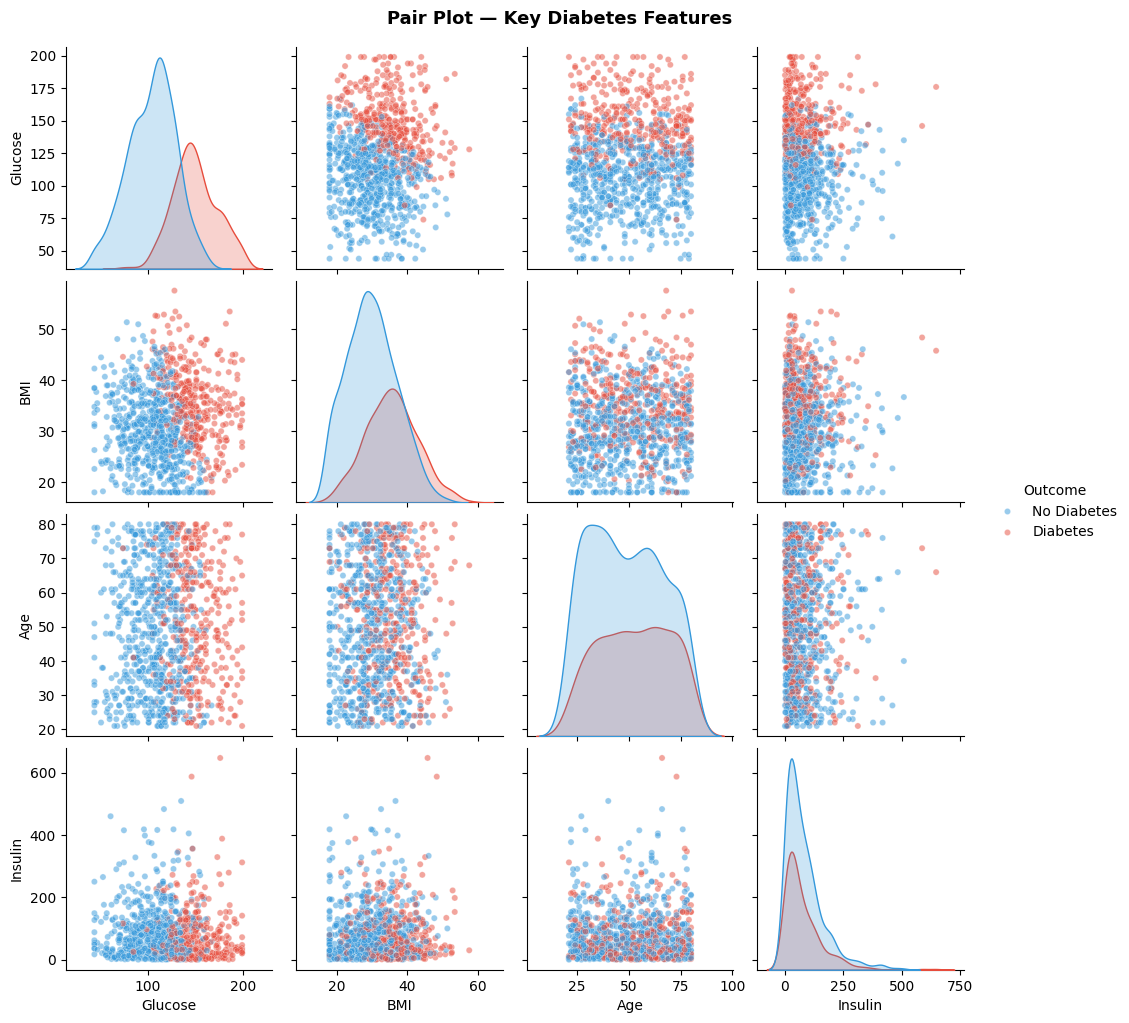

In [ ]:
# Pair plot for key features
key_feats = ['Glucose', 'BMI', 'Age', 'Insulin', TARGET_COL]
pair_df   = df[key_feats].copy()
pair_df[TARGET_COL] = pair_df[TARGET_COL].map({0:'No Diabetes', 1:'Diabetes'})
sns_pair = sns.pairplot(pair_df, hue=TARGET_COL,
                         palette={'No Diabetes':'#3498db','Diabetes':'#e74c3c'},
                         diag_kind='kde', plot_kws={'alpha':0.5, 's':20})
sns_pair.fig.suptitle('Pair Plot — Key Diabetes Features', y=1.02,
                       fontsize=13, fontweight='bold')
plt.show()

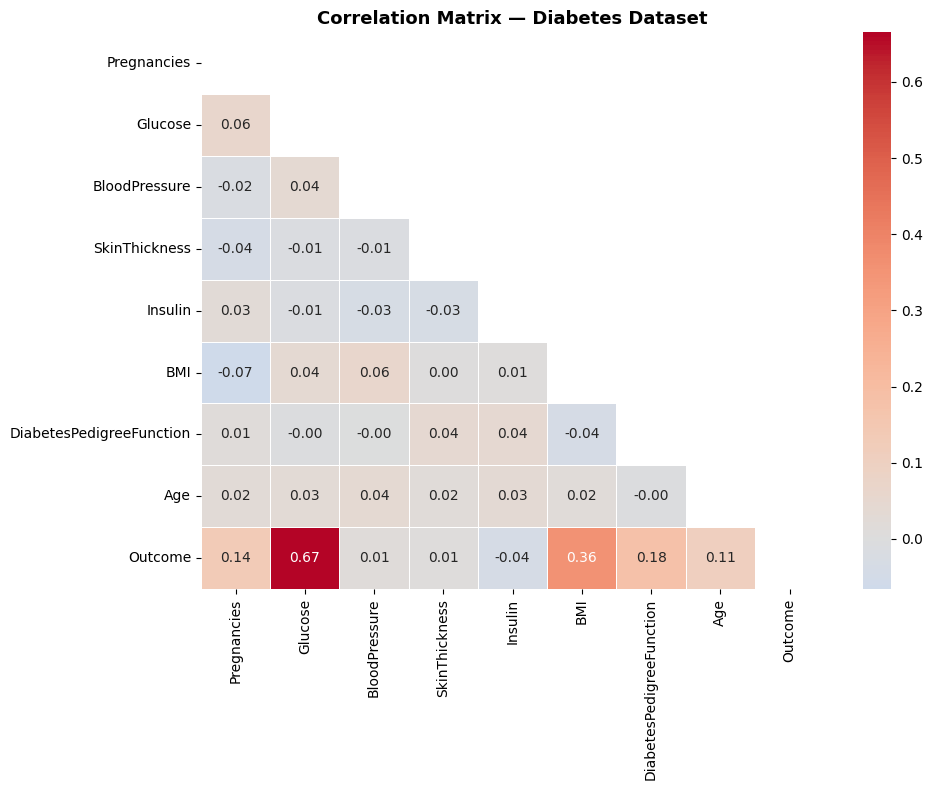

In [ ]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(10, 8))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix — Diabetes Dataset', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

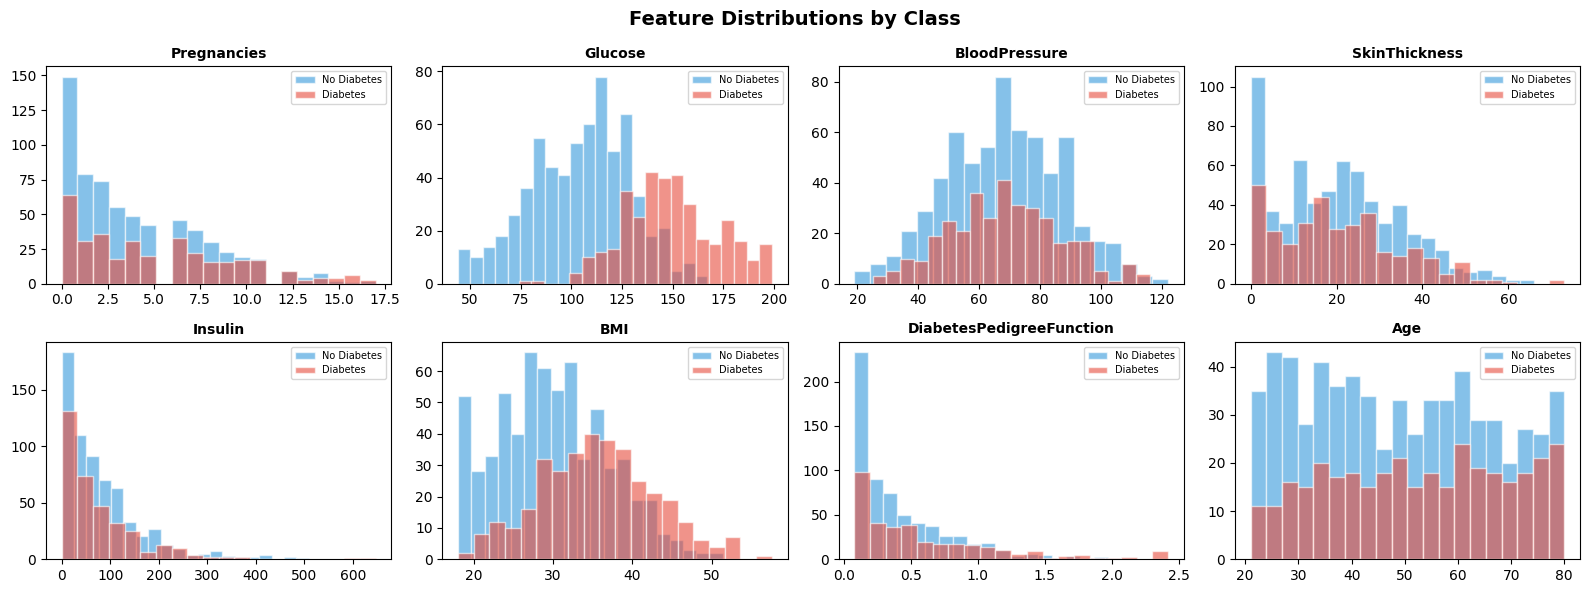

In [ ]:
# Feature distributions by class
features   = [c for c in df.columns if c != TARGET_COL]
n_cols = 4
n_rows = (len(features) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*4, n_rows*3))
axes = axes.flatten()

for i, feat in enumerate(features):
    for cls, color, label in [(0,'#3498db','No Diabetes'),(1,'#e74c3c','Diabetes')]:
        axes[i].hist(df[df[TARGET_COL]==cls][feat], bins=20, alpha=0.6,
                     color=color, label=label, edgecolor='white')
    axes[i].set_title(feat, fontsize=10, fontweight='bold')
    axes[i].legend(fontsize=7)
for i in range(len(features), len(axes)):
    axes[i].axis('off')

plt.suptitle('Feature Distributions by Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Replace physiologically impossible zeros with column median
df_clean = df.copy()
for col in ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']:
    median_val = df_clean.loc[df_clean[col] != 0, col].median()
    n_replaced = (df_clean[col] == 0).sum()
    df_clean[col] = df_clean[col].replace(0, median_val)
    print(f'  {col:30s}: replaced {n_replaced} zeros with median={median_val:.2f}')

X = df_clean.drop(columns=[TARGET_COL])
y = df_clean[TARGET_COL]
feature_names = X.columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'\nTrain : {X_train_s.shape}  |  Test : {X_test_s.shape}')

  Glucose                       : replaced 0 zeros with median=119.00
  BloodPressure                 : replaced 0 zeros with median=68.00
  SkinThickness                 : replaced 118 zeros with median=21.50
  Insulin                       : replaced 13 zeros with median=56.00
  BMI                           : replaced 0 zeros with median=31.60

Train : (800, 8)  |  Test : (200, 8)


In [ ]:
models_dict = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, C=1.0),
    'SVM':                 SVC(kernel='rbf', probability=True, random_state=42, C=1.0),
    'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=42,
                                                   max_depth=8, min_samples_split=5),
    'XGBoost':             XGBClassifier(n_estimators=200, learning_rate=0.1,
                                         max_depth=5, use_label_encoder=False,
                                         eval_metric='logloss', random_state=42,
                                         verbosity=0)
}

results = {}
cv      = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, clf in models_dict.items():
    clf.fit(X_train_s, y_train)
    y_pred  = clf.predict(X_test_s)
    y_proba = clf.predict_proba(X_test_s)[:, 1]
    cv_acc  = cross_val_score(clf, X_train_s, y_train, cv=cv,
                               scoring='accuracy').mean()
    results[name] = {
        'model'   : clf,
        'y_pred'  : y_pred,
        'y_proba' : y_proba,
        'accuracy': accuracy_score(y_test, y_pred),
        'roc_auc' : roc_auc_score(y_test, y_proba),
        'f1'      : f1_score(y_test, y_pred),
        'cv_acc'  : cv_acc
    }
    print(f'{name:22s} | Acc={results[name]["accuracy"]:.4f}  '
          f'AUC={results[name]["roc_auc"]:.4f}  '
          f'F1={results[name]["f1"]:.4f}  '
          f'CV={cv_acc:.4f}')

Logistic Regression    | Acc=0.9900  AUC=1.0000  F1=0.9859  CV=0.9812
SVM                    | Acc=0.9550  AUC=0.9898  F1=0.9353  CV=0.9500
Random Forest          | Acc=0.9200  AUC=0.9812  F1=0.8841  CV=0.9250
XGBoost                | Acc=0.9350  AUC=0.9901  F1=0.9078  CV=0.9387


=== Model Comparison ===
                     Accuracy  ROC-AUC  F1 Score  CV Acc
Logistic Regression     0.990   1.0000    0.9859  0.9812
SVM                     0.955   0.9898    0.9353  0.9500
Random Forest           0.920   0.9812    0.8841  0.9250
XGBoost                 0.935   0.9901    0.9078  0.9388


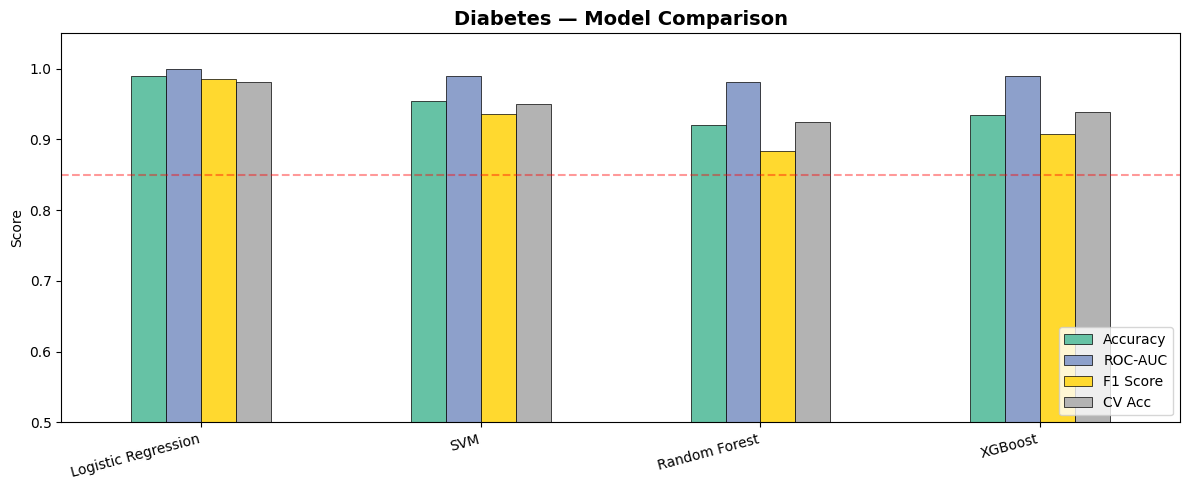

In [ ]:
metrics_df = pd.DataFrame({
    name: {
        'Accuracy': r['accuracy'],
        'ROC-AUC' : r['roc_auc'],
        'F1 Score': r['f1'],
        'CV Acc'  : r['cv_acc']
    } for name, r in results.items()
}).T.round(4)

print('=== Model Comparison ===')
print(metrics_df.to_string())

fig, ax = plt.subplots(figsize=(12, 5))
metrics_df[['Accuracy','ROC-AUC','F1 Score','CV Acc']].plot(
    kind='bar', ax=ax, colormap='Set2', edgecolor='black', linewidth=0.5
)
ax.set_title('Diabetes — Model Comparison', fontsize=14, fontweight='bold')
ax.set_ylabel('Score'); ax.set_ylim([0.5, 1.05])
ax.set_xticklabels(ax.get_xticklabels(), rotation=15, ha='right')
ax.axhline(y=0.85, color='red', linestyle='--', alpha=0.4)
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('diabetes_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

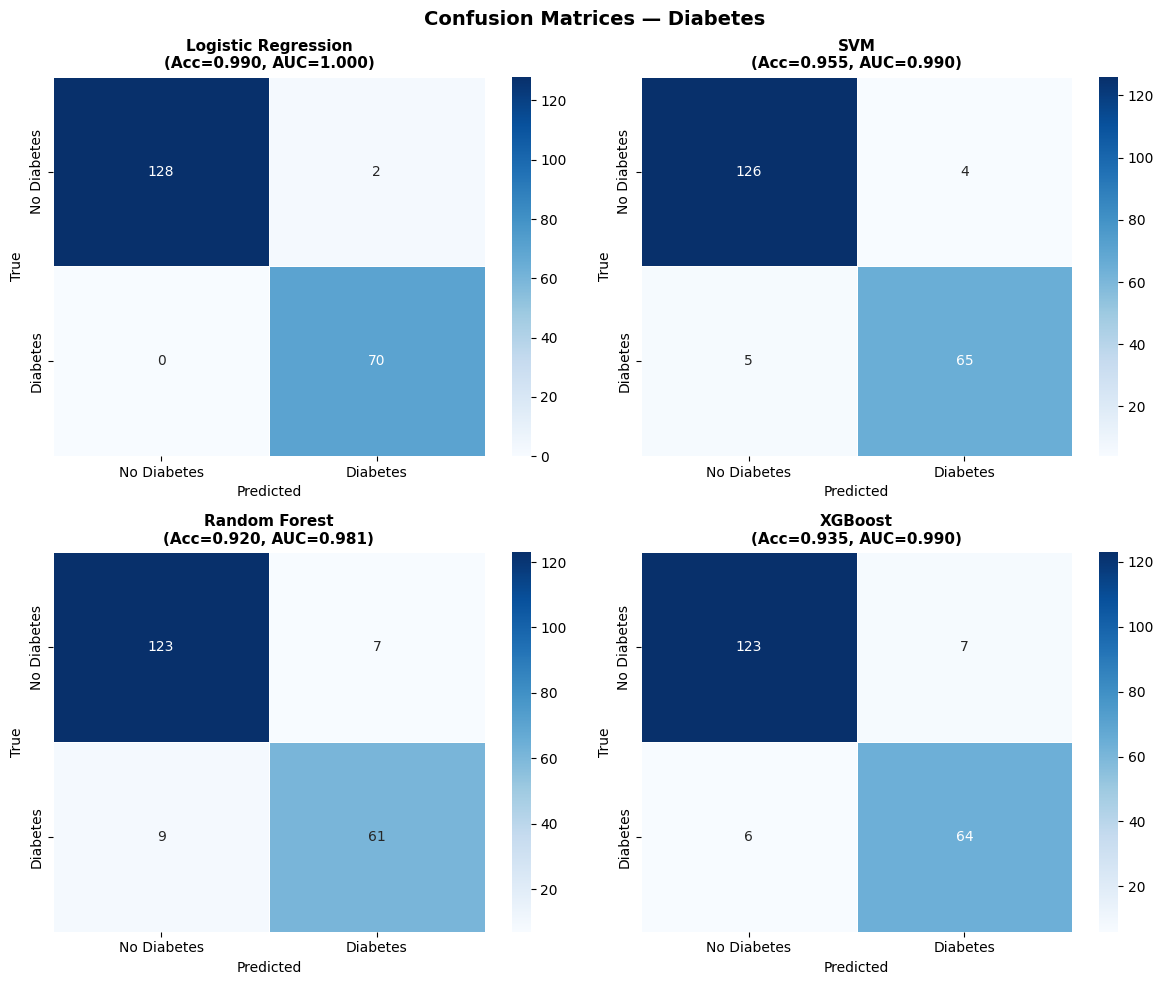

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, (name, r) in enumerate(results.items()):
    cm = confusion_matrix(y_test, r['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                linewidths=0.5, ax=axes[i])
    axes[i].set_title(f'{name}\n(Acc={r["accuracy"]:.3f}, AUC={r["roc_auc"]:.3f})',
                      fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Predicted'); axes[i].set_ylabel('True')

plt.suptitle('Confusion Matrices — Diabetes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('diabetes_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

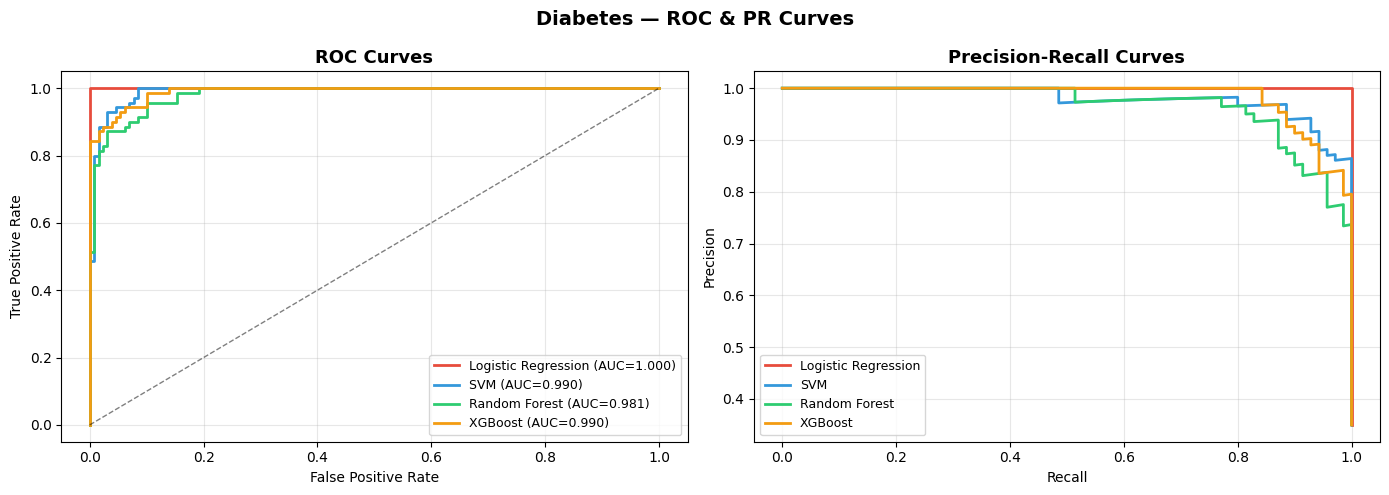

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['#e74c3c','#3498db','#2ecc71','#f39c12']

for (name, r), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, r['y_proba'])
    axes[0].plot(fpr, tpr, color=color, lw=2,
                 label=f'{name} (AUC={r["roc_auc"]:.3f})')
axes[0].plot([0,1],[0,1],'k--', lw=1, alpha=0.5)
axes[0].set_title('ROC Curves', fontsize=13, fontweight='bold')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)

for (name, r), color in zip(results.items(), colors):
    prec, rec, _ = precision_recall_curve(y_test, r['y_proba'])
    axes[1].plot(rec, prec, color=color, lw=2, label=name)
axes[1].set_title('Precision-Recall Curves', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)

plt.suptitle('Diabetes — ROC & PR Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('diabetes_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

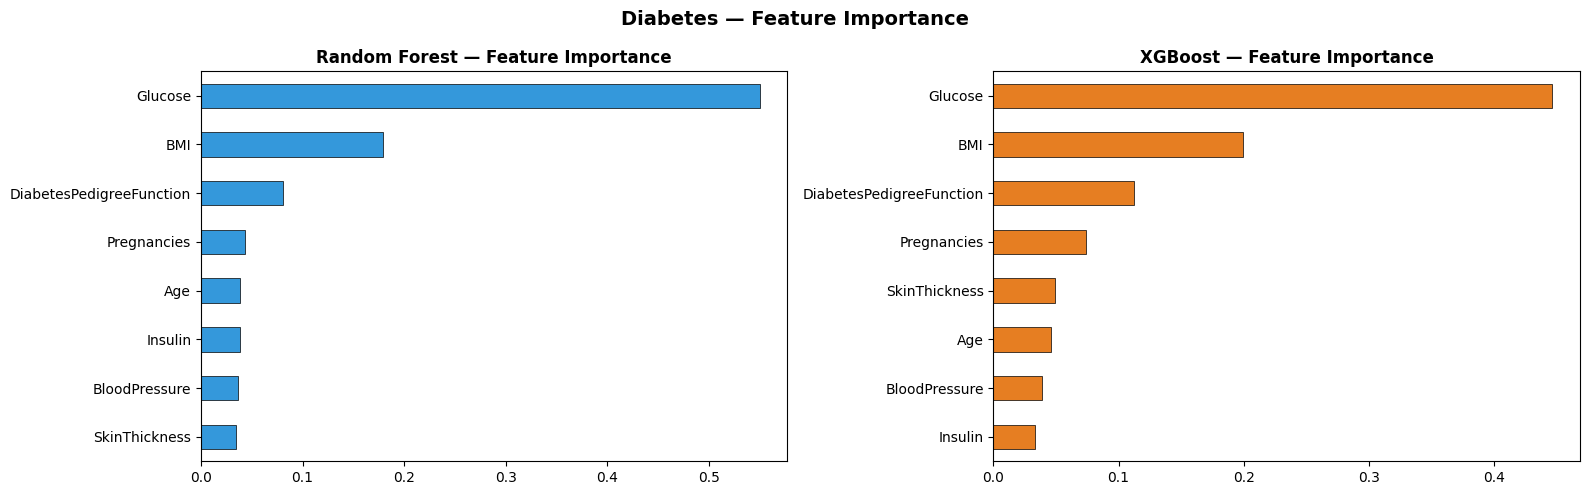

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

rf_imp = pd.Series(
    results['Random Forest']['model'].feature_importances_,
    index=feature_names
).sort_values(ascending=True)
rf_imp.plot(kind='barh', ax=axes[0], color='#3498db', edgecolor='black', linewidth=0.5)
axes[0].set_title('Random Forest — Feature Importance', fontsize=12, fontweight='bold')

xgb_imp = pd.Series(
    results['XGBoost']['model'].feature_importances_,
    index=feature_names
).sort_values(ascending=True)
xgb_imp.plot(kind='barh', ax=axes[1], color='#e67e22', edgecolor='black', linewidth=0.5)
axes[1].set_title('XGBoost — Feature Importance', fontsize=12, fontweight='bold')

plt.suptitle('Diabetes — Feature Importance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('diabetes_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
for name, r in results.items():
    print(f'\n{"="*55}')
    print(f'  {name}')
    print(f'{"="*55}')
    print(classification_report(y_test, r['y_pred'],
                                 target_names=CLASS_NAMES))


  Logistic Regression
              precision    recall  f1-score   support

 No Diabetes       1.00      0.98      0.99       130
    Diabetes       0.97      1.00      0.99        70

    accuracy                           0.99       200
   macro avg       0.99      0.99      0.99       200
weighted avg       0.99      0.99      0.99       200


  SVM
              precision    recall  f1-score   support

 No Diabetes       0.96      0.97      0.97       130
    Diabetes       0.94      0.93      0.94        70

    accuracy                           0.95       200
   macro avg       0.95      0.95      0.95       200
weighted avg       0.95      0.95      0.95       200


  Random Forest
              precision    recall  f1-score   support

 No Diabetes       0.93      0.95      0.94       130
    Diabetes       0.90      0.87      0.88        70

    accuracy                           0.92       200
   macro avg       0.91      0.91      0.91       200
weighted avg       0.92    

In [ ]:
best_model_name = max(results, key=lambda k: results[k]['roc_auc'])
best_model      = results[best_model_name]['model']
print(f'Best model (by ROC-AUC): {best_model_name}')

# Columns: Pregnancies, Glucose, BloodPressure, SkinThickness,
#          Insulin, BMI, DiabetesPedigreeFunction, Age
new_patient = pd.DataFrame([{
    'Pregnancies': 6, 'Glucose': 148, 'BloodPressure': 72,
    'SkinThickness': 35, 'Insulin': 0, 'BMI': 33.6,
    'DiabetesPedigreeFunction': 0.627, 'Age': 50
}])

# Replace zero insulin with median from training
ins_median = df_clean['Insulin'].median()
new_patient['Insulin'] = new_patient['Insulin'].replace(0, ins_median)

new_scaled = scaler.transform(new_patient)
pred_class = best_model.predict(new_scaled)[0]
pred_prob  = best_model.predict_proba(new_scaled)[0]

print(f'\nPatient Input  : {new_patient.iloc[0].to_dict()}')
print(f'Prediction     : {CLASS_NAMES[pred_class]}  (label={pred_class})')
print(f'Confidence     : No Diabetes={pred_prob[0]:.2%}  Diabetes={pred_prob[1]:.2%}')

Best model (by ROC-AUC): Logistic Regression

Patient Input  : {'Pregnancies': 6.0, 'Glucose': 148.0, 'BloodPressure': 72.0, 'SkinThickness': 35.0, 'Insulin': 56.0, 'BMI': 33.6, 'DiabetesPedigreeFunction': 0.627, 'Age': 50.0}
Prediction     : Diabetes  (label=1)
Confidence     : No Diabetes=1.04%  Diabetes=98.96%


In [ ]:
best = max(results, key=lambda k: results[k]['roc_auc'])
print('Diabetes Prediction — Results Summary')
print('='*55)
for name, r in results.items():
    star = ' ← BEST' if name == best else ''
    print(f'  {name:22s}  AUC={r["roc_auc"]:.4f}  Acc={r["accuracy"]:.4f}{star}')
print('='*55)
print(f'Best Model : {best}')
print(f'Best AUC   : {results[best]["roc_auc"]:.4f}')

Diabetes Prediction — Results Summary
  Logistic Regression     AUC=1.0000  Acc=0.9900 ← BEST
  SVM                     AUC=0.9898  Acc=0.9550
  Random Forest           AUC=0.9812  Acc=0.9200
  XGBoost                 AUC=0.9901  Acc=0.9350
Best Model : Logistic Regression
Best AUC   : 1.0000
